In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("housing.csv")

In [11]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Regionname,Propertycount
0,Abbotsford,25 Bloomburg St,2,house,1035000,property sold,Biggin,4/2/2016,2.5,3067,2,1,0.0,156,79.0,1900.0,Yarra,Northern Metropolitan,4019
1,Abbotsford,5 Charles St,3,house,1465000,property sold prior,Biggin,4/3/2017,2.5,3067,3,2,0.0,134,150.0,1900.0,Yarra,Northern Metropolitan,4019
2,Abbotsford,55a Park St,4,house,1600000,vendor bid,Nelson,4/6/2016,2.5,3067,3,1,2.0,120,142.0,2014.0,Yarra,Northern Metropolitan,4019
3,Abbotsford,124 Yarra St,3,house,1876000,property sold,Nelson,7/5/2016,2.5,3067,4,2,0.0,245,210.0,1910.0,Yarra,Northern Metropolitan,4019
4,Abbotsford,98 Charles St,2,house,1636000,property sold,Nelson,8/10/2016,2.5,3067,2,1,2.0,256,107.0,1890.0,Yarra,Northern Metropolitan,4019


In [12]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Propertycount
count,6847.000000,6.847000e+03,6847.000000,6847.000000,6847.000000,6847.000000,6819.000000,6847.000000,6847.000000,6847.000000,6847.000000
mean,2.977070,1.079246e+06,10.124814,3104.269461,2.950343,1.592814,1.606541,463.281145,142.959226,1964.295312,7432.043523
std,0.969548,6.732188e+05,5.978374,91.079330,0.969828,0.713867,0.944278,569.612425,82.392850,36.691828,4348.513574
min,1.000000,1.310000e+05,0.000000,3000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1830.000000,389.000000
25%,2.000000,6.300000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,165.000000,93.000000,1940.000000,4385.000000
50%,3.000000,8.925000e+05,9.200000,3083.000000,3.000000,1.000000,2.000000,402.000000,126.000000,1970.000000,6567.000000
75%,4.000000,1.336500e+06,13.000000,3148.000000,4.000000,2.000000,2.000000,640.000000,173.000000,2000.000000,10175.000000
max,8.000000,9.000000e+06,47.400000,3977.000000,9.000000,8.000000,10.000000,9838.000000,1561.000000,2018.000000,21650.000000


In [13]:
df.shape


(6847, 19)

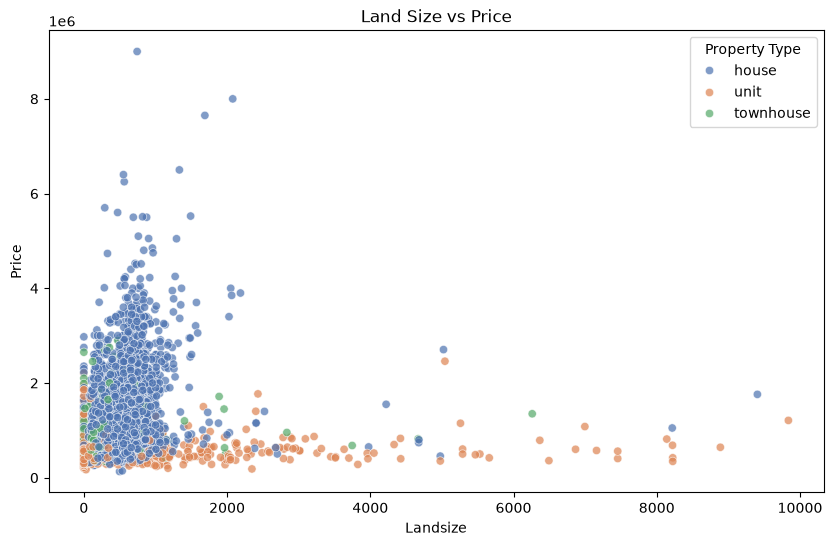

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Landsize',
    y='Price',
    hue='Type',
    palette='deep',
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)
plt.title('Land Size vs Price')
plt.xlabel('Landsize')
plt.ylabel('Price')
plt.legend(title='Property Type')
plt.show()

In [ ]:
The house has the highest increase in price by land size.

In [15]:
yearly_average = df.groupby('YearBuilt')['Price'].mean().reset_index()
yearly_average.head()

,YearBuilt,Price
0,1830.0,855000.0
1,1850.0,1347000.0
2,1854.0,3310000.0
3,1856.0,2260000.0
4,1860.0,1980000.0


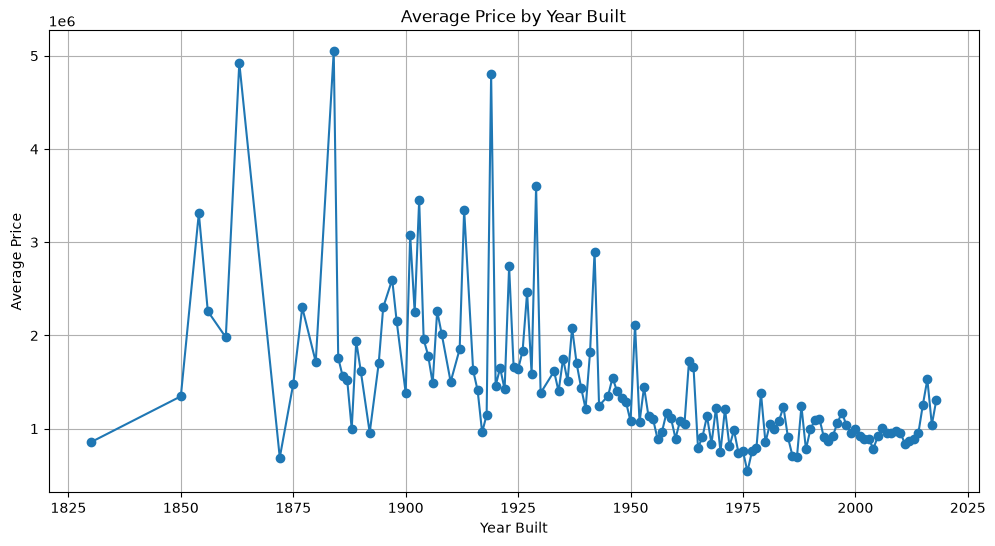

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_average['YearBuilt'], yearly_average['Price'], marker='o')
plt.title('Average Price by Year Built')
plt.xlabel('Year Built')
plt.ylabel('Average Price')
plt.title('Average Price by Year Built')
plt.grid(True)
plt.show()

Prices of 'homes' were extremely high in this dataset in the 1900s and shows a steady decrease into the 2000 with a minor increase in 2025.  Overall house prices decrease as newer homes are being built.

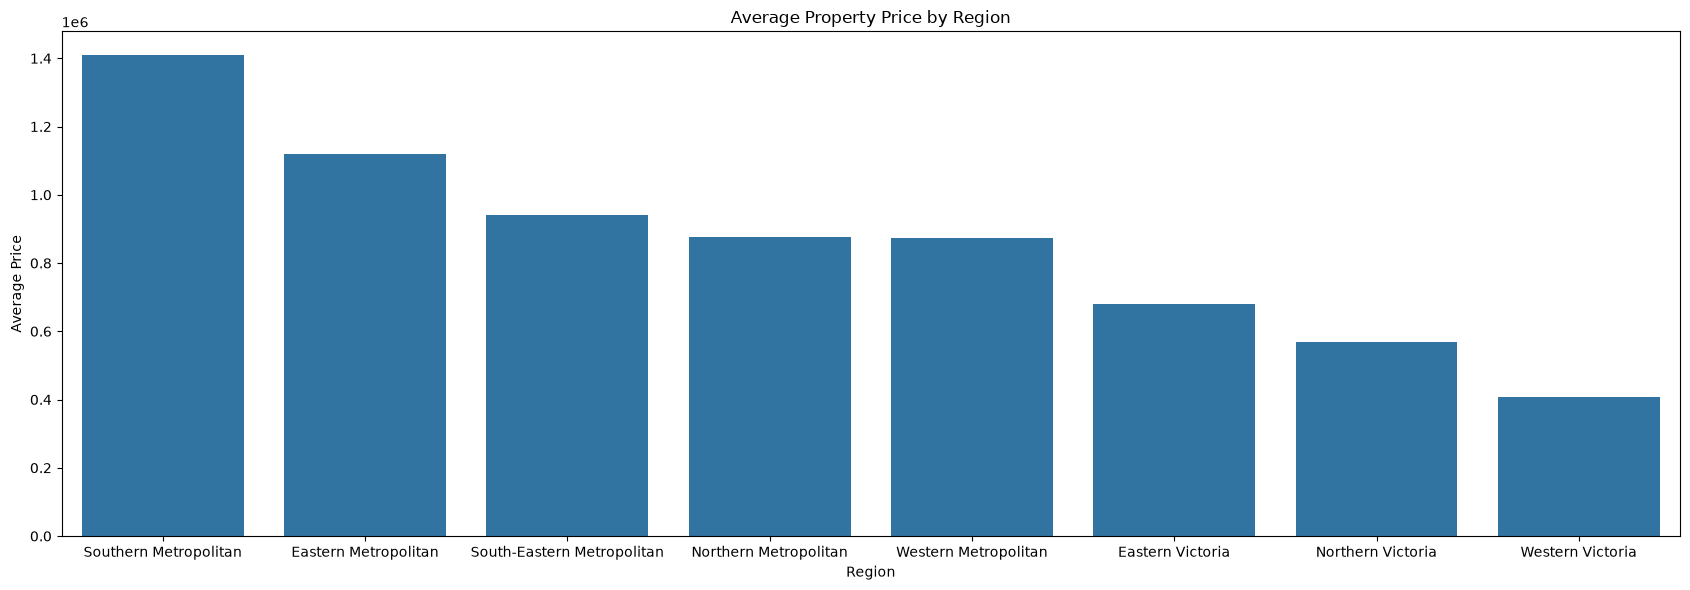

In [22]:
region_avg_price = (df.groupby('Regionname', as_index=False)['Price'].mean().sort_values('Price', ascending=False))

plt.figure(figsize=(17, 6))
sns.barplot(data=region_avg_price, x='Regionname', y='Price')
plt.title('Average Property Price by Region')
plt.xlabel('Region')
plt.ylabel('Average Price')
plt.tight_layout()
plt.show()

The Southern Metropolitan has the highest Average Price.

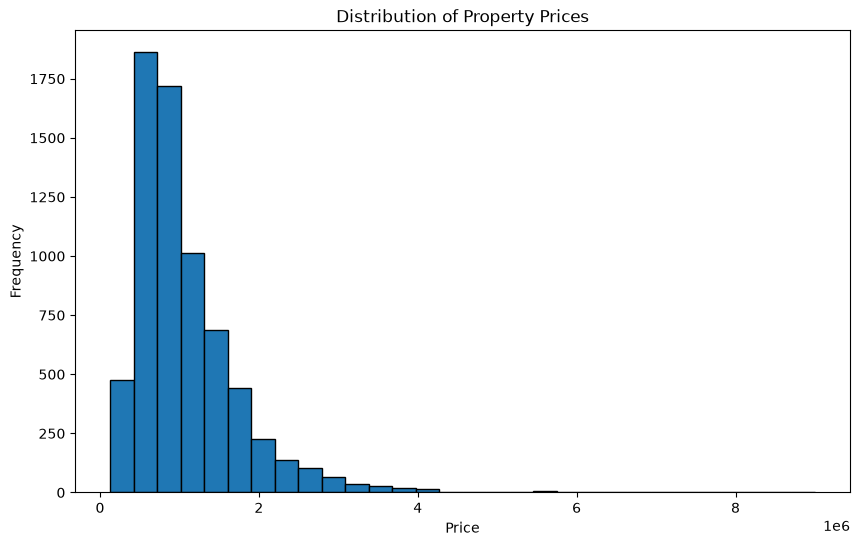

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=30, edgecolor='black')
plt.title('Distribution of Property Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

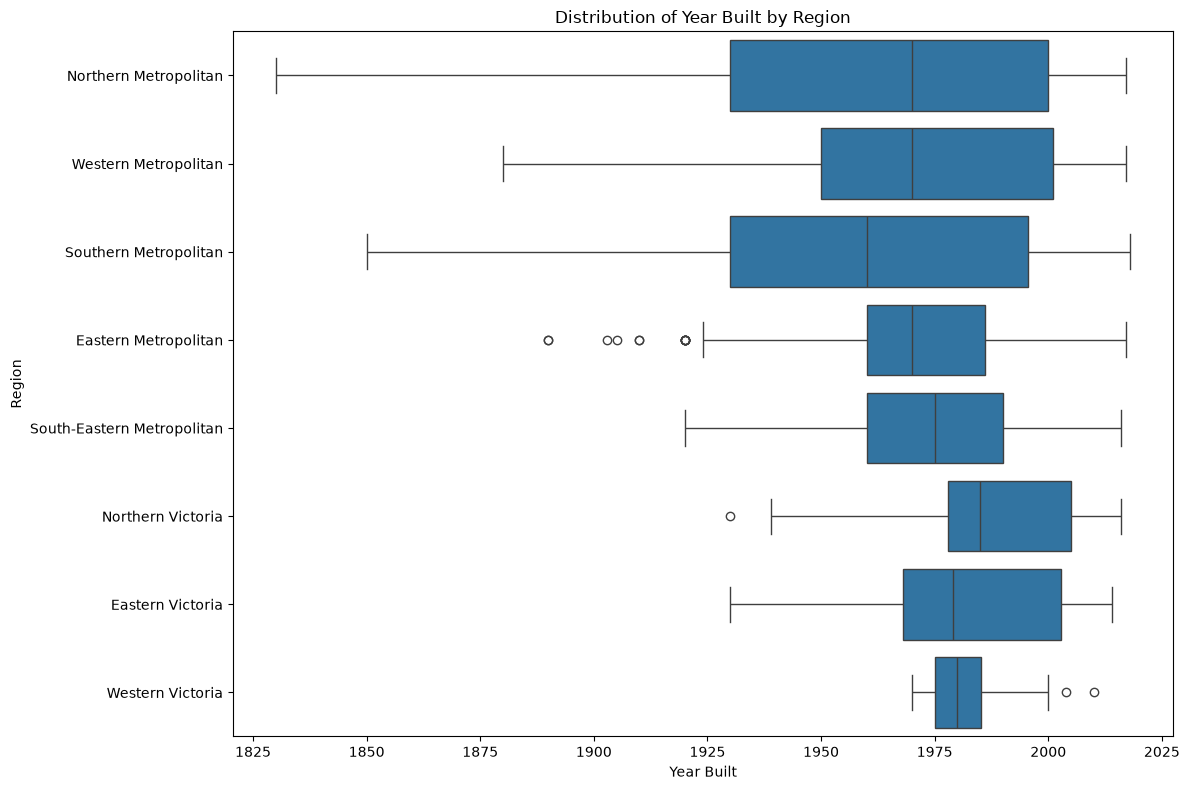

In [27]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df.dropna(subset=['YearBuilt', 'Regionname']),
    x='YearBuilt',
    y='Regionname',
    orient='h'
)
plt.title('Distribution of Year Built by Region')
plt.xlabel('Year Built')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

According to the data, Northern Metropolitan has the widest range of time (Year Built).  Western Victoria has the fewest after 2000.